In [2]:
import pandas as pd
import matplotlib.pyplot as plt

(1826, 13)
265 manglende temperaturer
Menstruation
MENSTRUATION    335
Name: count, dtype: int64


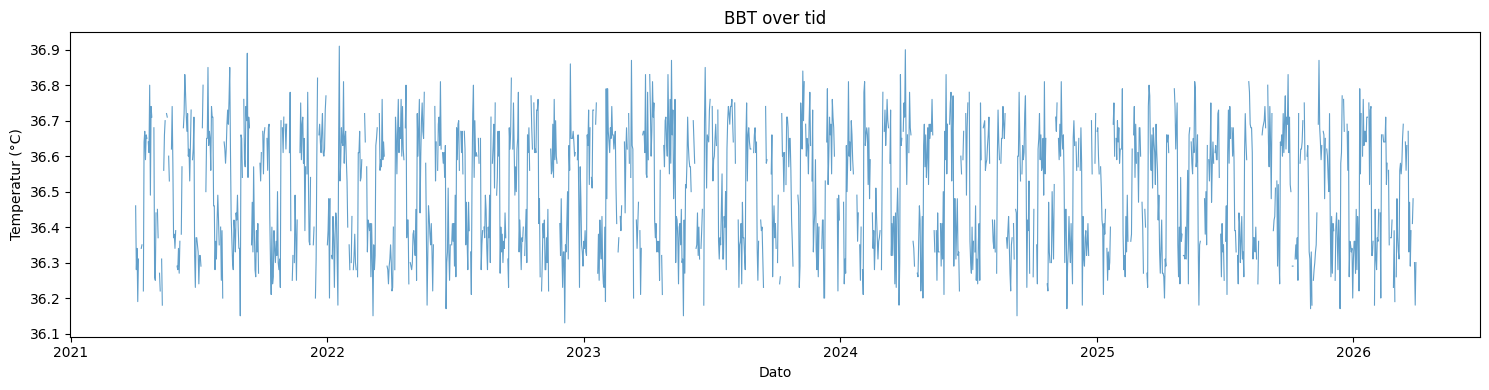

In [15]:
df = pd.read_csv("/Users/sahra/Documents/Sideprosjekt/cycle-tracker/cycle-tracker/data/synthetic/cycle_data_synthetic.csv")

df.head()

df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
print(df['Temperature'].isna().sum(), "manglende temperaturer")
print(df['Menstruation'].value_counts())

plt.figure(figsize=(15, 4))
plt.plot(df['Date'], df['Temperature'], alpha=0.7, linewidth=0.8)
plt.title('BBT over tid')
plt.xlabel('Dato')
plt.ylabel('Temperatur (°C)')
plt.tight_layout()
plt.show()

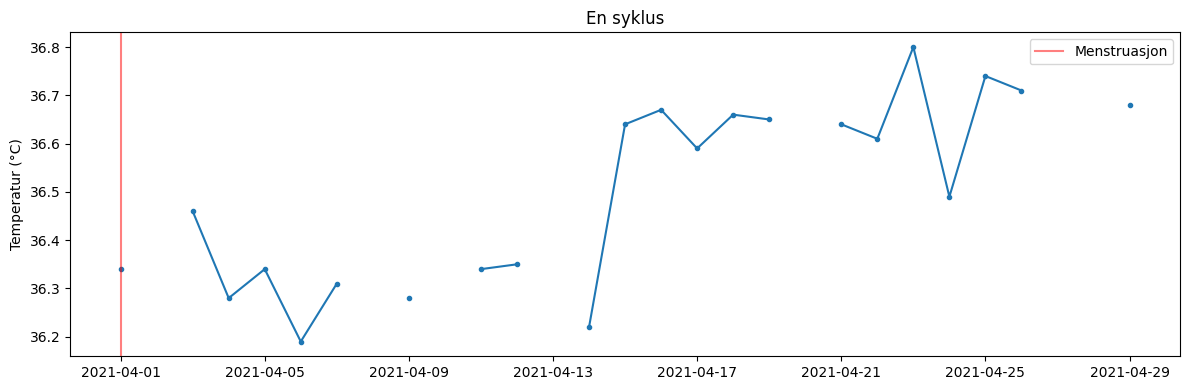

In [16]:
# Finn første syklus
df['is_menstruation'] = df['Menstruation'] == 'MENSTRUATION'
menstruation_dates = df[df['is_menstruation']]['Date']

# Ta ut første syklus
start = menstruation_dates.iloc[0]
end = menstruation_dates.iloc[5]  # ca en syklus frem

syklus = df[(df['Date'] >= start) & (df['Date'] < end)]

plt.figure(figsize=(12, 4))
plt.plot(syklus['Date'], syklus['Temperature'], marker='o', markersize=3)
plt.axvline(x=menstruation_dates.iloc[0], color='red', alpha=0.5, label='Menstruasjon')
plt.title('En syklus')
plt.ylabel('Temperatur (°C)')
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
# 1. Syklusdag - dag 1 er første menstruasjonsdag
df = df.sort_values('Date').reset_index(drop=True)

cycle_day = []
current_cycle_day = 0

for i, row in df.iterrows():
    if row['is_menstruation'] and (i == 0 or not df.loc[i-1, 'is_menstruation']):
        current_cycle_day = 1
    elif row['is_menstruation']:
        current_cycle_day += 1
    else:
        current_cycle_day += 1
    cycle_day.append(current_cycle_day)

df['cycle_day'] = cycle_day

In [18]:
# 2. Rullende gjennomsnittstemperatur (5-dagers vindu)
df['temp_rolling_mean'] = df['Temperature'].rolling(window=5, min_periods=1).mean()

In [19]:
# 3. Temperaturskift - har temp steget over 0.2 grader fra rullende snitt?
df['temp_shift'] = df['Temperature'] - df['temp_rolling_mean'].shift(6)
df['possible_ovulation'] = df['temp_shift'] > 0.2

In [20]:
# 4. Fase basert på temperaturskift
df['phase'] = 'follicular'
df.loc[df['possible_ovulation'], 'phase'] = 'ovulation'
df.loc[df['possible_ovulation'].shift(1, fill_value=False), 'phase'] = 'luteal'

print(df[['Date', 'Temperature', 'cycle_day', 'temp_rolling_mean', 'possible_ovulation', 'phase']].head(20))

         Date  Temperature  cycle_day  temp_rolling_mean  possible_ovulation  \
0  2021-04-01        36.34          1          36.340000               False   
1  2021-04-02          NaN          2          36.340000               False   
2  2021-04-03        36.46          3          36.400000               False   
3  2021-04-04        36.28          4          36.360000               False   
4  2021-04-05        36.34          5          36.355000               False   
5  2021-04-06        36.19          6          36.317500               False   
6  2021-04-07        36.31          7          36.316000               False   
7  2021-04-08          NaN          8          36.280000               False   
8  2021-04-09        36.28          9          36.280000               False   
9  2021-04-10          NaN         10          36.260000               False   
10 2021-04-11        36.34         11          36.310000               False   
11 2021-04-12        36.35         12   

In [21]:
# Imputering - lineær interpolasjon
df['Temperature'] = df['Temperature'].interpolate(method='linear')

# Sjekk at det ikke er NaN igjen
print(df['Temperature'].isna().sum(), "manglende temperaturer igjen")

# Oppdater rolling mean etter imputering
df['temp_rolling_mean'] = df['Temperature'].rolling(window=5, min_periods=1).mean()

0 manglende temperaturer igjen


In [22]:
# Split på tid - train 2021-2024, test 2025+
train = df[df['Date'] < '2025-01-01']
test = df[df['Date'] >= '2025-01-01']

print(f"Train: {len(train)} rader ({train['Date'].min().date()} - {train['Date'].max().date()})")
print(f"Test:  {len(test)} rader ({test['Date'].min().date()} - {test['Date'].max().date()})")

Train: 1371 rader (2021-04-01 - 2024-12-31)
Test:  455 rader (2025-01-01 - 2026-03-31)


In [ ]:
def detect_ovulation_confirmed(cycle_df, coverline):
    """
    Eggløsning bekreftes når 3 påfølgende temperaturer er over coverline.
    Returnerer indeksen til den dagen eggløsning er bekreftet.
    """
    temps = cycle_df['Temperature'].values
    confirmed_day = None
    
    for i in range(2, len(temps)):
        if (temps[i] > coverline and 
            temps[i-1] > coverline and 
            temps[i-2] > coverline):
            confirmed_day = i
            break
    
    return confirmed_day


def predict_fertile(cycle_df):
    coverline = calculate_coverline(cycle_df)
    if coverline is None:
        return cycle_df.assign(fertile=True)
    
    confirmed_day = detect_ovulation_confirmed(cycle_df, coverline)
    
    cycle_df = cycle_df.copy()
    if confirmed_day is None:
        # Eggløsning ikke bekreftet - alle dager er fertile
        cycle_df['fertile'] = True
    else:
        # Fertile frem til og med bekreftet dag, ikke-fertile etterpå
        cycle_df['fertile'] = True
        cycle_df.iloc[confirmed_day + 1:, cycle_df.columns.get_loc('fertile')] = False
    
    cycle_df['coverline'] = coverline
    cycle_df['ovulation_confirmed_day'] = confirmed_day
    return cycle_df


# Test på første syklus
first_cycle = train[train['cycle_day'] <= 35].copy().reset_index(drop=True)
result = predict_fertile(first_cycle)
print(f"Coverline: {result['coverline'].iloc[0]:.2f}°C")
print(f"Eggløsning bekreftet dag: {result['ovulation_confirmed_day'].iloc[0]}")
print(result[['Date', 'Temperature', 'cycle_day', 'fertile']].head(30))


def calculate_coverline(cycle_df):
    # Bruk kun de første 10 dagene (typisk follikulær fase)
    follicular = cycle_df[cycle_df['cycle_day'] <= 10]['Temperature']
    if len(follicular) == 0:
        return None
    return follicular.max() + 0.05



Coverline: 36.64°C
Eggløsning bekreftet dag: 19
         Date  Temperature  cycle_day  fertile
0  2021-04-01       36.340          1     True
1  2021-04-02       36.400          2     True
2  2021-04-03       36.460          3     True
3  2021-04-04       36.280          4     True
4  2021-04-05       36.340          5     True
5  2021-04-06       36.190          6     True
6  2021-04-07       36.310          7     True
7  2021-04-08       36.295          8     True
8  2021-04-09       36.280          9     True
9  2021-04-10       36.310         10     True
10 2021-04-11       36.340         11     True
11 2021-04-12       36.350         12     True
12 2021-04-13       36.285         13     True
13 2021-04-14       36.220         14     True
14 2021-04-15       36.640         15     True
15 2021-04-16       36.670         16     True
16 2021-04-17       36.590         17     True
17 2021-04-18       36.660         18     True
18 2021-04-19       36.650         19     True
19 2021-04-2

In [28]:
# Kopier cycle_number fra df til train
train = df[df['Date'] < '2025-01-01'].copy()

# Kjør predict_fertile på hver syklus
results = []
for cycle_num in train['cycle_number'].unique():
    cycle = train[train['cycle_number'] == cycle_num].copy().reset_index(drop=True)
    if len(cycle) > 10:
        result = predict_fertile(cycle)
        results.append(result)

all_cycles = pd.concat(results).reset_index(drop=True)

print(f"Totalt: {len(all_cycles)} dager")
print(f"Fertile dager: {all_cycles['fertile'].sum()}")
print(f"Ikke-fertile dager: {(~all_cycles['fertile']).sum()}")
print(f"Andel fertile: {all_cycles['fertile'].mean():.1%}")

Totalt: 1371 dager
Fertile dager: 857
Ikke-fertile dager: 514
Andel fertile: 62.5%


In [ ]:
# Kjør predict_fertile på testdata
test = df[df['Date'] >= '2025-01-01'].copy()

results_test = []
for cycle_num in test['cycle_number'].unique():
    cycle = test[test['cycle_number'] == cycle_num].copy().reset_index(drop=True)
    if len(cycle) > 10:
        result = predict_fertile(cycle)
        results_test.append(result)

test_cycles = pd.concat(results_test).reset_index(drop=True)

print(f"Totalt: {len(test_cycles)} dager")
print(f"Fertile dager: {test_cycles['fertile'].sum()}")
print(f"Ikke-fertile dager: {(~test_cycles['fertile']).sum()}")
print(f"Andel fertile: {test_cycles['fertile'].mean():.1%}")